In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lake_ice_helpers import lake_files
from count_analysis_helpers import *
import os
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection  import train_test_split

In [ ]:
data_path = None #Add your path here
model_path = None
visualization_path = None

In [4]:
df_full_clean = pd.read_csv(data_path+r'\cleaned_lake_era5summary_for_network.csv',index_col=0,low_memory=False)

In [5]:
df_full_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18316 entries, 0 to 18315
Columns: 981 entries, station_id to ice_cover_duration
dtypes: float64(974), int64(2), object(5)
memory usage: 137.2+ MB


In [6]:
df_full_clean.columns[:25]

Index(['station_id', 'year', 'ice_on', 'ice_off', 'ice_on_doy', 'ice_off_doy',
       'lake_id', 'country', 'lake_name', 'lat_wgs84', 'lon_wgs84',
       'altitude_m', 'area_ha', 'depth_max_m', 'log_area_ha', 'CA', 'FI', 'NO',
       'SE', 'US', 'tair_count_1_current', 'tair_count_2_current',
       'tair_count_3_current', 'tair_count_4_current', 'tair_count_5_current'],
      dtype='object')

In [ ]:


def clean_and_sort_network_table(df,extra_drop_columns=None):
    '''
    Function to clean and modify network data frame for PyTorch training.
    Input df should be created as shown in notebook named as 'creating_lake_era5summary_csv.ipynb'
    This function makes sure all columns are in correct data format even if data drame is opened from .csv-file.
    NOTE: This function assumes that our TARGET COLUMN IS 'ice_cover_duration',
         and this should be the last column of input data frame.
    Funtion sorts dataframe based on 'year'-column, and removes other target and object type columns.
    With parameter extra_drop_columns you can add more columns to drop.
    '''
    drop_columns = df.select_dtypes(include=['object']).columns.to_list() + ['lake_id','ice_on_doy','ice_off_doy']

    # Dropping non-numerical and redundant target-type columns
    df_network = df.drop(columns=drop_columns).copy()
    if extra_drop_columns is not None:
        df_network = df_network.drop(columns=extra_drop_columns)
    # Turning all columns to dtype float64. Some methods we will use expect similarity of dtypes.
    df_network = df_network.astype('float64') 
    # Sort frame based on year
    df_network = df_network.sort_values('year')
    df_network = df_network.reset_index(drop=True)

    return df_network


## Dropping redundant columns
* all 'count'-columns are useless for modelling.
* 'median' does not bring that much information when 'mean' is already included.
    * Based on statistical tables of MinMax-scaled data frames, 'mean' has 'meaningfull' value (not just zero) more often.
    * 'median' might clarify some observations, if something unusual has happened.
* All 'count'- and median'-columns (or 'mean'-columns instead of 'median'?) could be dropped and no statistically significant change would happen.
* Here we choose to drop both 'count'- and median'-columns to clarify importance inference.

In [14]:
extra_drop_columns = set([x for x in df_full_clean.columns if ('count' in x) | ('median' in x)])
#extra_drop_columns = set([x for x in df_full_clean.columns if 'count' in x])
extra_drop_columns.remove('country') # We want to keep column 'country' in our data

In [15]:
'country' in extra_drop_columns

False

In [16]:
df_network = clean_and_sort_network_table(df=df_full_clean,extra_drop_columns=extra_drop_columns)

In [17]:
df_network.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Columns: 781 entries, year to ice_cover_duration
dtypes: float64(781)
memory usage: 109.1 MB


In [18]:
df_network[df_network['year']<2010].shape # Total size of train and validation data

(16678, 781)

In [19]:
# Saving describtion table:
#df_network_describe_table = df_network.describe().T
#df_network_describe_table.to_csv(data_path+r'\df_network_lake_era5summary_describe_table.csv')

In [20]:
split_index = df_network[df_network['year']<2010].shape[0]
# This is index where we split training+validation data to include years before 2010.
# Data for years 2010-2023 is our test data.
split_index 

16678

In [21]:
16678/18316 # Ratio of data included in train+validation set

0.9105699934483512

In [22]:
# 'Randomly'choosing train and validation indexes:
train_indexes,validation_indexes = train_test_split(np.arange(0,split_index),train_size=0.9,random_state=7)

Creating class for our dataset:

In [23]:
class LakeIceDataset(Dataset):

    '''
    class to create Pytorch Dataset for cleaned lake ice data. We assume that target variable is in last column.
    inputs:
        - data_path: path to cleaned and modified duration data frame, which is created with function 'make_duration_table'.
        - device: this gives information about which device we use for network training.
        - feature_transform: A transfrom method from sklearn.preprocessing.
    ouputs:
        - X: features as torch.tensor, with device as input device and columns transformed based on given feature_transform.
        - y: target variable as torch.tensor implemented in chosen device.

    '''
    def __init__(self,data_path=None,df=None,device='cpu',feature_transform=None,scikit_feature_transform=None):
        if data_path is not None:
            self.data_path = data_path
            self.duration_table = pd.read_csv(self.data_path,index_col=0)
        elif df is not None:
            self.duration_table = df.copy()
        else:
            return ValueError
        
        self.features = [col for col in self.duration_table.columns[:-1]]
        self.target = self.duration_table.columns[-1]
        
        if scikit_feature_transform is not None:
            self.feature_transform = scikit_feature_transform
            self.duration_table.iloc[:,:-1] = self.feature_transform.transform(self.duration_table.iloc[:,:-1])
        elif feature_transform is not None:
            self.feature_transform = feature_transform
            self.duration_table.iloc[:,:-1] = self.feature_transform(self.duration_table.iloc[:,:-1])

        self.duration_table = torch.tensor(self.duration_table.to_numpy(),dtype=torch.float32).to(device,non_blocking=True) # last parameter to make cuda work with Dataloaders

    def __len__(self):
        return len(self.duration_table)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        X = self.duration_table[idx,:-1]
        y = self.duration_table[idx,-1]
        return X,y

In [24]:
#from count_network_library import LakeIceDataset

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'

# Fitting MinMaxScaler to features based on train indexes of sorted data frame.
scaler = MinMaxScaler().fit(df_network.iloc[train_indexes,:-1])

# Creating network datasets:
train_dataset = LakeIceDataset(df=df_network.iloc[train_indexes,:],
                               device=device,
                               scikit_feature_transform=scaler)

validation_dataset = LakeIceDataset(df=df_network.iloc[validation_indexes,:],
                               device=device,
                               scikit_feature_transform=scaler)

test_dataset = LakeIceDataset(df=df_network.iloc[split_index:,:],
                               device=device,
                               scikit_feature_transform=scaler)


In [25]:
df_network.shape,len(train_dataset),len(validation_dataset),len(test_dataset)

((18316, 781), 15010, 1668, 1638)

Dataloader only for train data.

In [30]:
from torch.utils.data import DataLoader

BS = 128
torch.manual_seed(7)
train_dataloader = DataLoader(train_dataset,
                               batch_size=BS,
                               shuffle=True,
                               pin_memory=False,
                               drop_last=True,
                               #pin_memory_device=device
                               )

Validation data splitted to tensors:

In [31]:
validation_X = validation_dataset.duration_table[:,:-1]
validation_y = validation_dataset.duration_table[:,-1]

## A function to train and validate model.
* Keeping track on best model for validation dataset. The best validation model will be our final model.
    * The idea is to initialize model_info_dict to have information about train, validation, test indexes.
    * We update the model and opimizer information during training and model is saved to given path.
* We can choose to print mid-results with 'given print_gap', which is the amount epochs between the result prints.

In [32]:
from datetime import datetime
from copy import deepcopy

def train_epochs(model,
                 n_train_data,
                 n_epochs,
                 loss_fn,
                 optimizer,
                 train_dataloader,
                 best_validation_loss=10**9,
                 model_info_dict = None,
                 print_result_gap=0,
                 model_path=None,
                 model_name = None,
                 validation_X=None,
                 validation_y=None):
  
    '''
    This function trains input model with data in train_dataloader and evaluates performance in validation/test-data.

    inputs:
        - model: A Pytorch network based on mechanisms of torch.nn.Module.
        - n_train_data: the total amount of train data, as individual observations.
        - n_epochs: number of epochs we use for training the network.
        - loss_fn: the loss-function we optimize. For example, some of the ready made loss-functions in torch.nn.
        - optimizer: an optimizer from torch.optim.
        - train_dataloader: Pytorch style Dataloader for train-data.
        - best_validation_loss: optional initial value for validation loss. You can give initial value if you continue model training etc.
        - print_result_gap: print loss results for every 'print_result_gap' -epochs if input parameter has value above zero.
        - model_path: optional parameter. This is path to folder where would like to save model results.
        - model_name: optional parameter. This is name for our model, if we want to save it to given model_path.
        - validation_X: validation/test-data in torch.tensor format. Should be in same device as train-data.
        - validation_y: validation/test-target variable in torch.tensor format. Should be in same device as train-data.

    outputs:
        - train_loss_avgs: average train-loss in each epoch.
        - validation_loss_avgs: average validation-loss in each epoch.

    '''
  
    train_loss_avgs = [0] * n_epochs
    validation_loss_avgs = [0] * n_epochs

    # model_info_dict is initialized here if needed:
    if (model_info_dict is None) & (model_path is not None) & (model_name is not None):
        model_info_dict = {}

  
    for epoch in range(n_epochs):
        # Looping through batches in training mode:
        model.train()
        for X_batch, y_batch in train_dataloader:   
            n_batch = len(y_batch)
            preds = model(X_batch)
            loss = loss_fn(preds,y_batch.unsqueeze(1))
            train_loss_avgs[epoch] += loss.item()*n_batch/n_train_data # Output of loss is MSE. This gives correct weight for each batch.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if (validation_X is not None) & (validation_y is not None):
            # After training, optionally change to evaluation mode:
            model.eval()
            with torch.no_grad():
            # No loader for validation dataset. We can directly make predictions for whole validation data.
                validation_preds = model(validation_X)
                validation_loss = loss_fn(validation_preds,validation_y.unsqueeze(1)).item()
                validation_loss_avgs[epoch] = validation_loss
                if (validation_loss < best_validation_loss) & (model_path is not None) & (model_name is not None):
                    
                    time = datetime.now().strftime('%Y%m%d_%H%M%S')
                    saving_path = model_path + model_name + '.pth'
                    
                    # Saving model information if this option was chosen:
                    # Initial model_info_dict could/should include information about training,validation and test indexes.
                    model_info_dict['epoch'] = epoch
                    model_info_dict['model_state_dict'] = deepcopy(model.state_dict())
                    model_info_dict['optimizer_state_dict'] = deepcopy(optimizer.state_dict())
                    model_info_dict['validation_loss'] = validation_loss
                    model_info_dict['training_time'] = time

                    torch.save(model_info_dict,saving_path)

                    ## Optional and more simple way to save model:
                    # torch.save({'epoch':epoch,
                    #             'model_state_dict':deepcopy(model.state_dict()),
                    #             'optimizer_state_dict':deepcopy(optimizer.state_dict()),
                    #             'validation_loss':validation_loss,
                    #             'training_time':time},
                    #             saving_path)

                    best_validation_loss = validation_loss

        if print_result_gap >0:
            if ((epoch+1)%print_result_gap == 0) | (epoch==0):
                print(f'Epoch: {epoch+1}')
                print(f'Train average loss: {train_loss_avgs[epoch]:.4f}')
                print(f'Validation average loss: {validation_loss_avgs[epoch]:.4f}')
                print()


    # Final outputs 
    if (validation_X is not None) & (validation_y is not None):
        return train_loss_avgs,validation_loss_avgs
    else:
        return train_loss_avgs

In [33]:
class LakeERA5summaryEV_LeakyReLU(nn.Module):
    def __init__(self,layer_sizes:list,leaky_slopes:list,dropout_ps):

        super().__init__()

        self.layers = []
        
        for idx in range(1,len(layer_sizes)):
            layer = nn.Linear(layer_sizes[idx-1],layer_sizes[idx])
            self.layers.append(layer)
            self.layers.append(nn.LeakyReLU(negative_slope=leaky_slopes[idx-1]))
            if (idx-1) < len(dropout_ps):
                self.layers.append(nn.Dropout(p=dropout_ps[idx-1]))

        # Output layer is Linear in this case:
        self.layers.append(nn.Linear(layer_sizes[-1],1))

        self.model = nn.Sequential(*self.layers)

    def forward(self,x):
        return self.model(x)

Choosing model hyperparameters:

In [34]:
#from count_network_library import LakeIceBasicEV,train_epochs

torch.manual_seed(7)

initial_layer_sizes = [len(train_dataset.features),512,256,128,64,32]
initial_leaky_slopes = [0.27 for i in range(len(initial_layer_sizes)-1)]
dropout_ps = [0.5]

initial_model = LakeERA5summaryEV_LeakyReLU(layer_sizes=initial_layer_sizes,
                                        leaky_slopes=initial_leaky_slopes,
                                        dropout_ps=dropout_ps).to(device)
initial_model

LakeERA5summaryEV_LeakyReLU(
  (model): Sequential(
    (0): Linear(in_features=780, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.27)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.27)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.27)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): LeakyReLU(negative_slope=0.27)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): LeakyReLU(negative_slope=0.27)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Selecting loss function and optimizer: 

In [35]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(initial_model.parameters(),lr=0.001)

In [ ]:
torch.manual_seed(7)
n_epochs = 1000
train_losses,validation_losses = train_epochs(model = initial_model,
                                        n_train_data=len(train_dataset), # train_set included all train data.
                                        n_epochs=n_epochs,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        train_dataloader=train_dataloader,
                                        best_validation_loss=10**9,
                                        model_info_dict={'train_indexes':train_indexes,
                                                         'validation_indexes':validation_indexes,
                                                         'split_index_for_test_data':split_index},
                                        print_result_gap=50,
                                        #model_path=model_path,
                                        #model_name='LakeERA5summaryEV_LeakyReLU_Linear_output_reduced_columns_final_3rd',
                                        validation_X=validation_X,
                                        validation_y=validation_y,
                                        )


Epoch: 1
Train average loss: 5270.2187
Validation average loss: 1105.6553

Epoch: 50
Train average loss: 350.2981
Validation average loss: 885.3491

Epoch: 100
Train average loss: 255.2451
Validation average loss: 806.1661

Epoch: 150
Train average loss: 226.5924
Validation average loss: 595.2271

Epoch: 200
Train average loss: 202.4232
Validation average loss: 354.5881

Epoch: 250
Train average loss: 186.3293
Validation average loss: 420.0582

Epoch: 300
Train average loss: 169.3853
Validation average loss: 436.9697

Epoch: 350
Train average loss: 159.7329
Validation average loss: 321.2544

Epoch: 400
Train average loss: 152.2348
Validation average loss: 347.8277

Epoch: 450
Train average loss: 140.2988
Validation average loss: 382.1955

Epoch: 500
Train average loss: 141.7353
Validation average loss: 333.7291

Epoch: 550
Train average loss: 134.3570
Validation average loss: 404.8785

Epoch: 600
Train average loss: 122.0147
Validation average loss: 393.3326

Epoch: 650
Train average l

In [ ]:
# # torch.save({'epoch':n_epochs,
# #              'model_state_dict':deepcopy(initial_model.state_dict()),
# #              'optimizer_state_dict':deepcopy(optimizer.state_dict()),},
# #              model_path + 'LakeERA5summaryEV_LeakyReLU_Linear_output_reduced_columns_20250418_best_train_final_3rd' + '.pth')

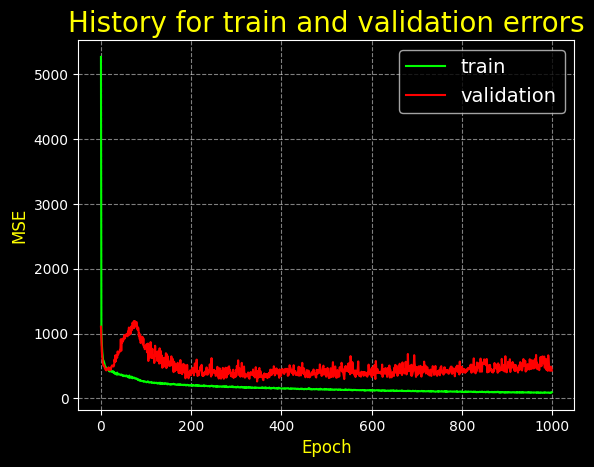

In [38]:
with plt.style.context('dark_background'):
    fig = plt.figure()
    plt.grid(linestyle='--',alpha=0.5)
    plt.plot(train_losses,color='lime',label='train')
    plt.plot(validation_losses,color='red',label='validation')
    plt.legend(fontsize=14)
    plt.title('History for train and validation errors',color='yellow',fontsize=20)
    plt.xlabel('Epoch',color='yellow',fontsize=12)
    plt.ylabel('MSE',color='yellow',fontsize=12);

In [39]:
np.min(train_losses),np.min(validation_losses)

(83.30270399160976, 259.98980712890625)

In [40]:
def preds_vs_true_scatter(preds,true,title=None):
    '''
    Helper to quickly visualize model predictions vs true values.
    Inputs:
        - preds: model predictions. Expected to be numpy array or alike.
        - true: true values. Expected to be numpy array or alike.
        - title: optional title for visualization.
        - return_fig: returns figure object if True.
    '''
    with plt.style.context('dark_background'):
        fig = plt.figure()
        plt.grid(linestyle='--',alpha=0.5)
        plt.scatter(x=true,
                    y=preds,
                    color='lime',
                    s=7,
                    alpha=0.5,
                    )
        plt.ylabel('Preds',fontsize=14,color='yellow')
        plt.xlabel('True',fontsize=14,color='yellow')
        xy = np.arange(0,366)
        plt.plot(xy,xy,color='red',linestyle='--')
        if title is not None:
            plt.title(title,fontsize=20,color='yellow')
        else:
            plt.title('Model preds vs true',fontsize=20,color='yellow')
            
        return fig

## Short analysis for best model predictions
* Model that was saved during training had the smallest validation error.
* We open this model here from file and do analysis about the quality of predictions.

In [41]:
leaky_model_checkpoint = torch.load(model_path+'LakeERA5summaryEV_LeakyReLU_Linear_output_reduced_columns_final_3rd.pth',weights_only=False)

In [42]:
leaky_model_checkpoint['validation_loss']

259.98980712890625

In [43]:
model_from_file = LakeERA5summaryEV_LeakyReLU(layer_sizes=initial_layer_sizes,
                                        leaky_slopes=initial_leaky_slopes,
                                        dropout_ps=dropout_ps).to(device)
model_from_file.load_state_dict(leaky_model_checkpoint['model_state_dict'])
model_from_file

LakeERA5summaryEV_LeakyReLU(
  (model): Sequential(
    (0): Linear(in_features=780, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.27)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.27)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.27)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): LeakyReLU(negative_slope=0.27)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): LeakyReLU(negative_slope=0.27)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [44]:
model_from_file.eval() # Remember this!!! Otherwise nn.Dropout is active (in training mode).
leakyReLU_train_preds = model_from_file(train_dataset.duration_table[:,:-1]).cpu().detach().squeeze().numpy()
leakyReLU_train_preds_sorted = np.sort(leakyReLU_train_preds)

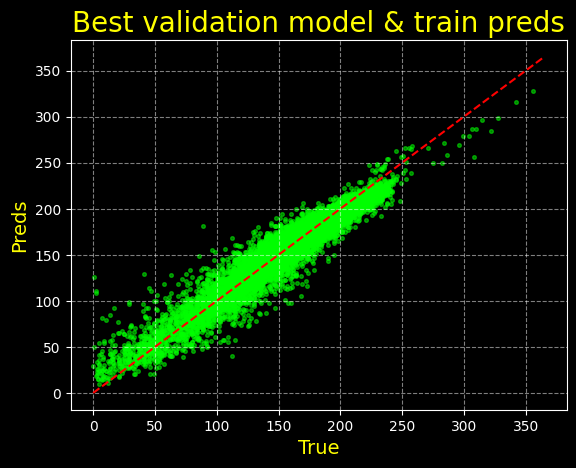

In [45]:
preds_vs_true_scatter(preds=leakyReLU_train_preds,
                      true=train_dataset.duration_table[:,-1].cpu().detach().numpy(),
                      title='Best validation model & train preds')

In [46]:
df_train_plot = pd.DataFrame({'Preds':leakyReLU_train_preds,
                            'True':train_dataset.duration_table[:,-1].cpu().detach().numpy(),
                            'country':df_full_clean.sort_values('year').iloc[train_indexes,:].loc[:,'country']})
df_train_plot['country_int'],_ = pd.factorize(df_train_plot['country'])
df_train_plot['squared_errors'] = (df_train_plot['Preds']-df_train_plot['True'])**2
df_train_plot.head()

,Preds,True,country,country_int,squared_errors
2601,121.772751,133.0,SE,0,126.051125
17150,180.696320,186.0,CA,1,28.129026
5527,156.905502,170.0,SE,0,171.465866
16164,130.789124,109.0,NO,2,474.765900
7204,172.866638,166.0,SE,0,47.150719


In [47]:
df_train_plot.groupby('country')['squared_errors'].mean()

country
CA     87.156677
FI     96.087692
NO     77.849426
SE    153.937439
US     60.138649
Name: squared_errors, dtype: float32

In [48]:
df_train_plot.groupby('country')['True'].mean()

country
CA    161.927933
FI    172.610733
NO    155.926956
SE    152.352844
US    136.038345
Name: True, dtype: float32

In [49]:
np.unique(df_train_plot['country'],return_counts=True)

(array(['CA', 'FI', 'NO', 'SE', 'US'], dtype=object),
 array([1346, 3522,  575, 9228,  339], dtype=int64))

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

def preds_vs_true_country_scatter(df,
                                  countries,
                                  full_country_names,
                                  country_colors,
                                  nrows,
                                  ncols,
                                  title=None):
   

   with plt.style.context('dark_background'):
      fig,axes  = plt.subplots(nrows=nrows,ncols=ncols,figsize=(8,4*nrows),layout='constrained')
      axes = axes.flatten()
      xy = np.arange(0,366)
      for i in range(len(countries)):
         axes[i].grid(linestyle='--',alpha=0.5)
         axes[i].plot(xy,xy,color='red',linestyle='--')
         sub_set = df.loc[df.country==countries[i],:]
         axes[i].scatter(x=sub_set['True'],
                     y=sub_set['Preds'],
                              color=country_colors[i],
                              s=7,
                              alpha=0.7,
                              label=full_country_names[i])
         axes[i].legend(markerscale=3,fontsize=14)
      
         axes[i].set_xlabel('True',
                            fontsize=12,
                            color='yellow')
              
         axes[i].set_ylabel('Preds',
                            fontsize=12,
                            color='yellow')
      if len(countries)%2 != 0:
         axes[-1].set_axis_off()
      if title is not None:
         fig.suptitle(title,
                      fontsize=20,
                      color='cyan')
      else:
         fig.suptitle('Train predictions vs true values per country',
          fontsize=20,
          color='cyan')
         
      return fig

In [51]:
country_colors = ['cyan','lime','purple','orange','yellow']
countries = np.unique(df_train_plot.country)
full_country_names = ['Canada','Finland','Norway','Sweden','USA']

import random
random.shuffle(country_colors)
train_visualization_countries = preds_vs_true_country_scatter(df=df_train_plot,
                                                              countries=countries,
                                                              full_country_names=full_country_names,
                                                              country_colors=country_colors,
                                                              nrows=3,
                                                              ncols=2,
                                                              title='Fully connected ERA5-network train-preds vs true',
                                                              )

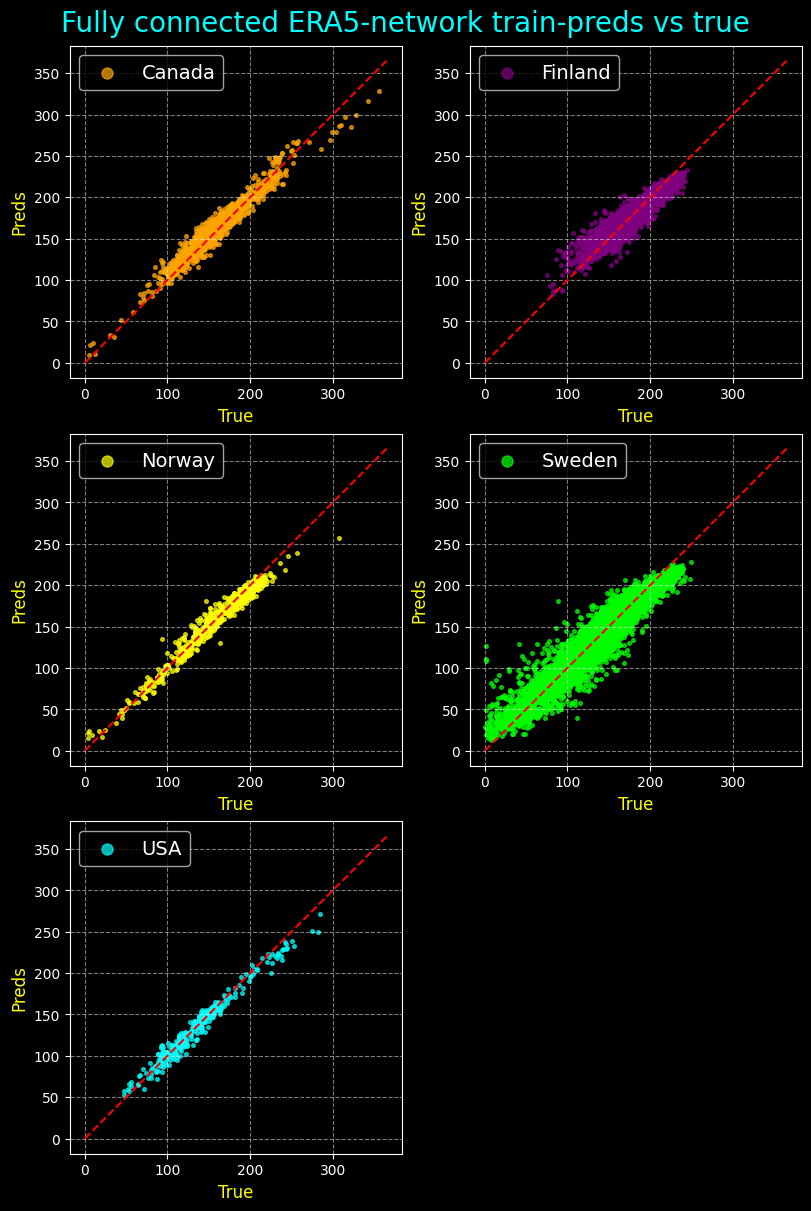

In [52]:
train_visualization_countries

In [53]:
#train_visualization_countries.savefig(visualization_path+'LakeERA5summaryEV_LeakyReLU_train_countries.png',bbox_inches='tight')
plt.close('all')

## MSE testing for validation data
* There is one absurdly large prediction. The real ice cover duration for this case was 344 days. 
    * This is confusing the validation MSE results.
    * We would gain significantly lower MSE for test data, if choose model with lower train MSE. This can be seen in MSE-results for the model of last epoch. This model had absurdly high validation MSE, and at the same time low train MSE and low test MSE.
* It appears we need to somehow cap the results for this network from the higher end too.
* Confidence intervals are wider with small datasets.
* Model has problems to predict Swedish lakes.

In [54]:
model_from_file.eval() # Remember this!!! Otherwise nn.Dropout is active (in training mode).
leakyReLU_validation_preds = model_from_file(validation_X).cpu().detach().squeeze().numpy()

In [55]:
MSE_validation = short_mse_analysis(preds=leakyReLU_validation_preds,
                   true=pd.Series(validation_y.cpu().detach().numpy()),
                   return_variables=True)

MSE: 259.9898
Squared error std scaled: 23.945404843023205
95% lower bound: 213.05681363658078
95% upper bound: 306.9228006212317


In [56]:
df_validation_plot = pd.DataFrame({'Preds':leakyReLU_validation_preds,
                            'True':validation_dataset.duration_table[:,-1].cpu().detach().numpy(),
                            'country':df_full_clean.sort_values('year').iloc[validation_indexes,:].loc[:,'country']})
df_validation_plot['country_int'],_ = pd.factorize(df_validation_plot['country'])
df_validation_plot['squared_errors'] = (df_validation_plot['Preds']-df_validation_plot['True'])**2
df_validation_plot.head()

,Preds,True,country,country_int,squared_errors
6804,182.840424,192.0,SE,0,83.897842
1122,206.721069,211.0,SE,0,18.309248
11123,199.858505,197.0,FI,1,8.171052
13403,169.377350,168.0,FI,1,1.897093
9941,31.516399,38.0,SE,0,42.037079


In [57]:
df_validation_plot.groupby('country')['squared_errors'].mean()

country
CA    295.621246
FI    131.359299
NO    341.921387
SE    305.914520
US    134.065323
Name: squared_errors, dtype: float32

In [58]:
df_validation_plot.groupby('country')['True'].mean()

country
CA    162.263519
FI    172.792496
NO    166.093750
SE    150.345856
US    150.590912
Name: True, dtype: float32

In [59]:
np.unique(df_validation_plot['country'],return_counts=True)

(array(['CA', 'FI', 'NO', 'SE', 'US'], dtype=object),
 array([ 148,  400,   64, 1012,   44], dtype=int64))

In [60]:
random.shuffle(country_colors)

validation_visualization_countries = preds_vs_true_country_scatter(df=df_validation_plot,
                                                              countries=countries,
                                                              full_country_names=full_country_names,
                                                              country_colors=country_colors,
                                                              nrows=3,
                                                              ncols=2,
                                                              title='Fully connected ERA5-network validation-preds vs true',
                                                              )


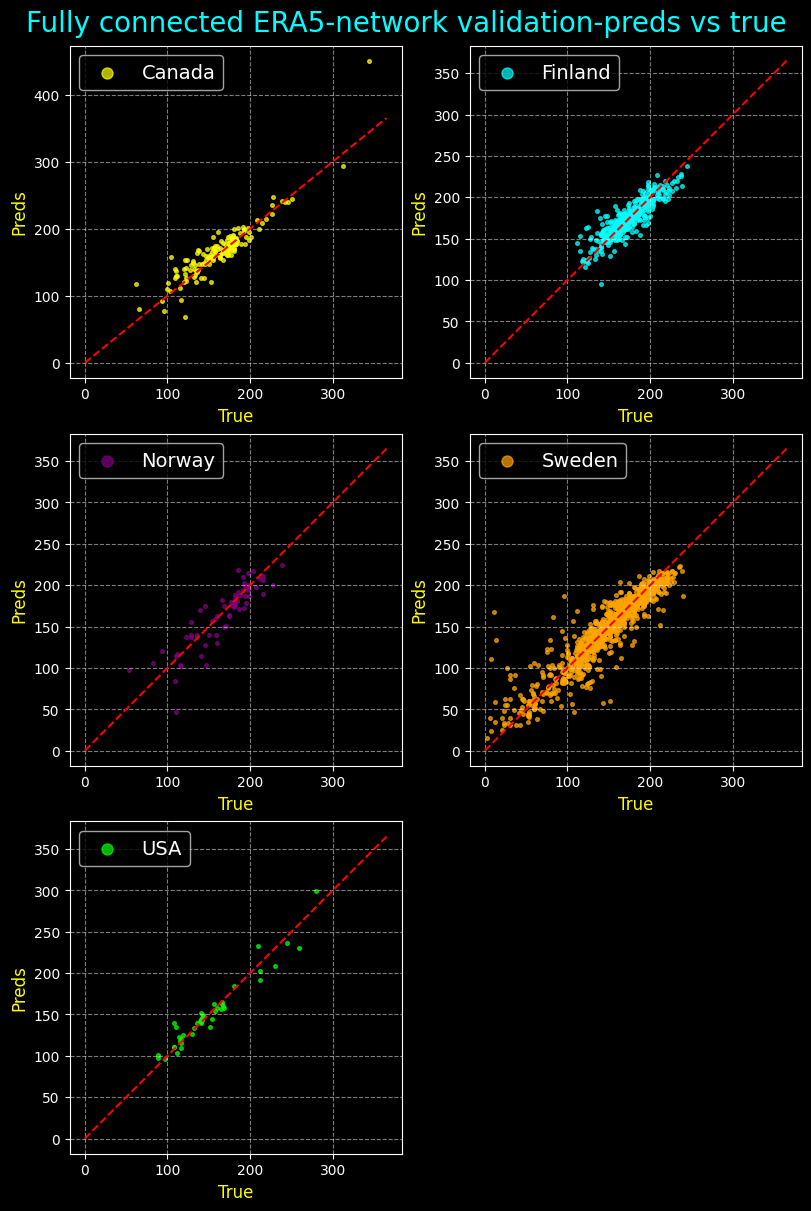

In [61]:
validation_visualization_countries

In [62]:
#validation_visualization_countries.savefig(visualization_path+'LakeERA5summaryEV_LeakyReLU_validation_countries.png',bbox_inches='tight')
plt.close('all')

## MSE testing for test data
* No totally absurd predictions, but MSE is clearly higher than with train and validation data.
* Confidence intervals are wider with small datasets.
* Problems to predict Swedish lakes, as with other models too.

In [63]:
model_from_file.eval() # Remember this!!! Otherwise nn.Dropout is active (in training mode).
leakyReLU_test_preds = model_from_file(test_dataset.duration_table[:,:-1]).cpu().detach().squeeze().numpy()
leakyReLU_test_preds_sorted = np.sort(leakyReLU_test_preds)

In [64]:
MSE_leakyReLU_test_preds = short_mse_analysis(preds=leakyReLU_test_preds,
                                                true=pd.Series(test_dataset.duration_table[:,-1].cpu().detach().numpy()),
                                                return_variables=True)

MSE: 577.33014
Squared error std scaled: 56.70989788538191
95% lower bound: 466.1787393048077
95% upper bound: 688.4815390155048


In [65]:
MSE_leakyReLU_test_preds

{'mse': 577.33014,
 'SE_of_mse': 56.70989788538191,
 'squared_errors': array([   8.233369,  106.34986 ,  513.6404  , ...,  151.41585 ,
         381.18784 , 1023.2599  ], dtype=float32),
 '95%_lower': 466.1787393048077,
 '95%_upper': 688.4815390155048}

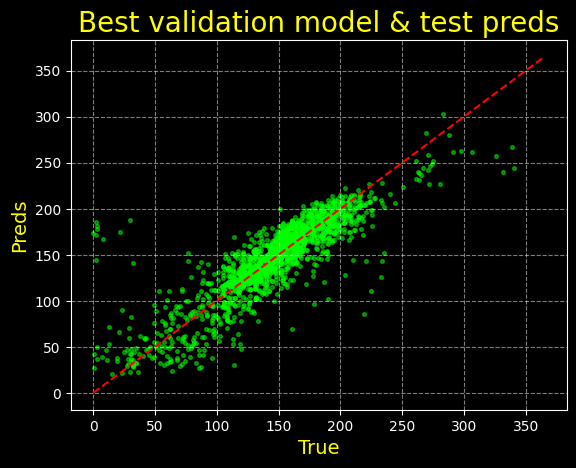

In [66]:
preds_vs_true_scatter(preds=leakyReLU_test_preds,
                      true=test_dataset.duration_table[:,-1].cpu().detach().numpy(),
                      title='Best validation model & test preds',
                      )

In [67]:
df_test_plot = pd.DataFrame({'Preds':leakyReLU_test_preds,
                            'True':test_dataset.duration_table[:,-1].cpu().detach().numpy(),
                            'country':df_full_clean.sort_values('year').iloc[split_index:,:].loc[:,'country']})
df_test_plot['country_int'],_ = pd.factorize(df_test_plot['country'])
df_test_plot['squared_errors'] = (df_test_plot['Preds']-df_test_plot['True'])**2
df_test_plot.head()

,Preds,True,country,country_int,squared_errors
12685,137.869385,135.0,FI,0,8.233369
5003,128.687393,139.0,SE,1,106.349861
9738,206.663635,184.0,SE,1,513.640381
17997,119.332214,108.0,US,2,128.419083
15526,163.474319,177.0,NO,3,182.944031


In [68]:
df_test_plot.groupby('country')['squared_errors'].mean()

country
CA     504.356506
FI     332.822876
NO    1249.307983
SE     906.968506
US     305.737061
Name: squared_errors, dtype: float32

In [69]:
np.unique(df_test_plot['country'],return_counts=True)

(array(['CA', 'FI', 'NO', 'SE', 'US'], dtype=object),
 array([ 84, 752,  62, 581, 159], dtype=int64))

In [70]:
random.shuffle(country_colors)
test_visualization_countries = preds_vs_true_country_scatter(df=df_test_plot,
                                                              countries=countries,
                                                              full_country_names=full_country_names,
                                                              country_colors=country_colors,
                                                              nrows=3,
                                                              ncols=2,
                                                              title='Fully connected ERA5-network test-preds vs true',
                                                              )

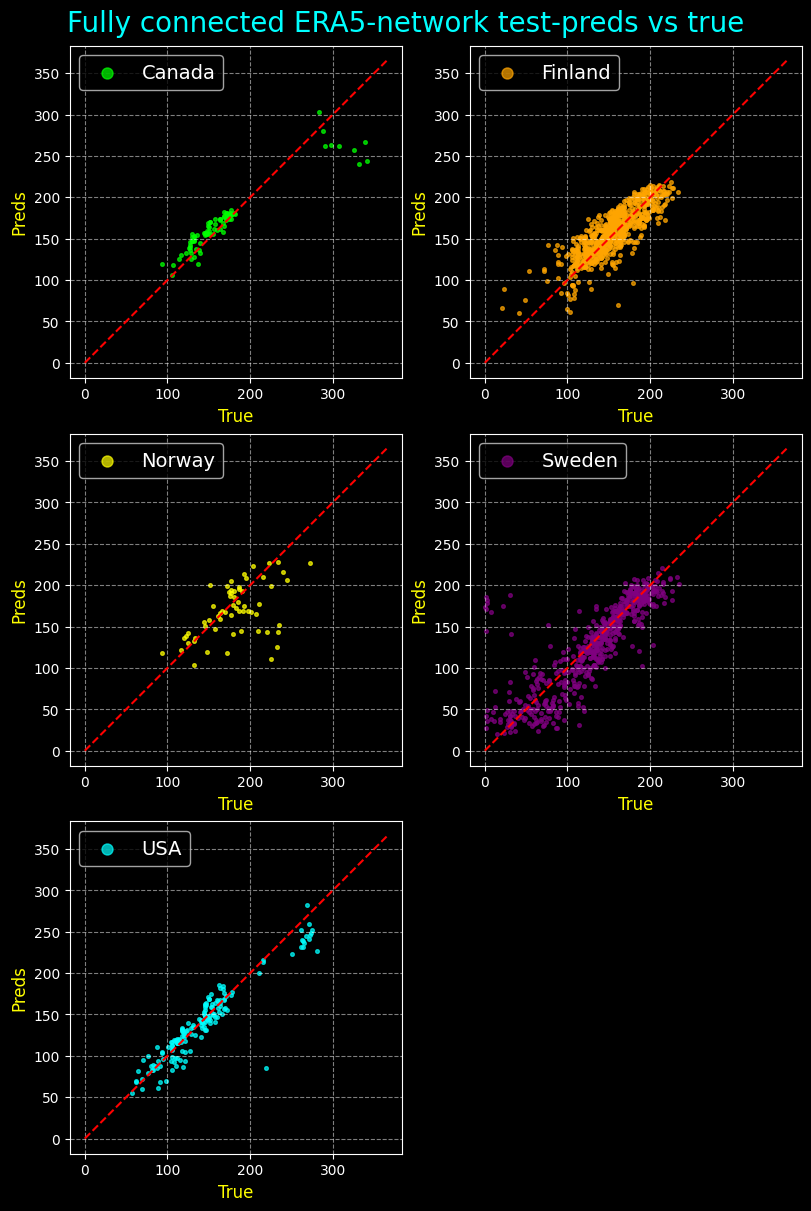

In [71]:
test_visualization_countries

In [72]:
#test_visualization_countries.savefig(visualization_path+'LakeERA5summaryEV_LeakyReLU_test_countries.png',bbox_inches='tight')
plt.close('all')